In [14]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

In [15]:
img = cv2.imread("../images/sunflower.png", cv2.IMREAD_GRAYSCALE)
img = np.float32(img) / 255.0


wavelet = "haar"
cA, (cH, cV, cD) = pywt.dwt2(img, wavelet)


threshold = 0.05
cH_thresh = pywt.threshold(cH, threshold, mode="soft")
cV_thresh = pywt.threshold(cV, threshold, mode="soft")
cD_thresh = pywt.threshold(cD, threshold, mode="soft")

In [16]:
compressed_img = pywt.idwt2((cA, (cH_thresh, cV_thresh, cD_thresh)), wavelet)


compressed_img = np.clip(compressed_img, 0, 1)
compressed_img_uint8 = np.uint8(compressed_img * 255)


if compressed_img.shape != img.shape:
    compressed_img = cv2.resize(compressed_img, (img.shape[1], img.shape[0]))

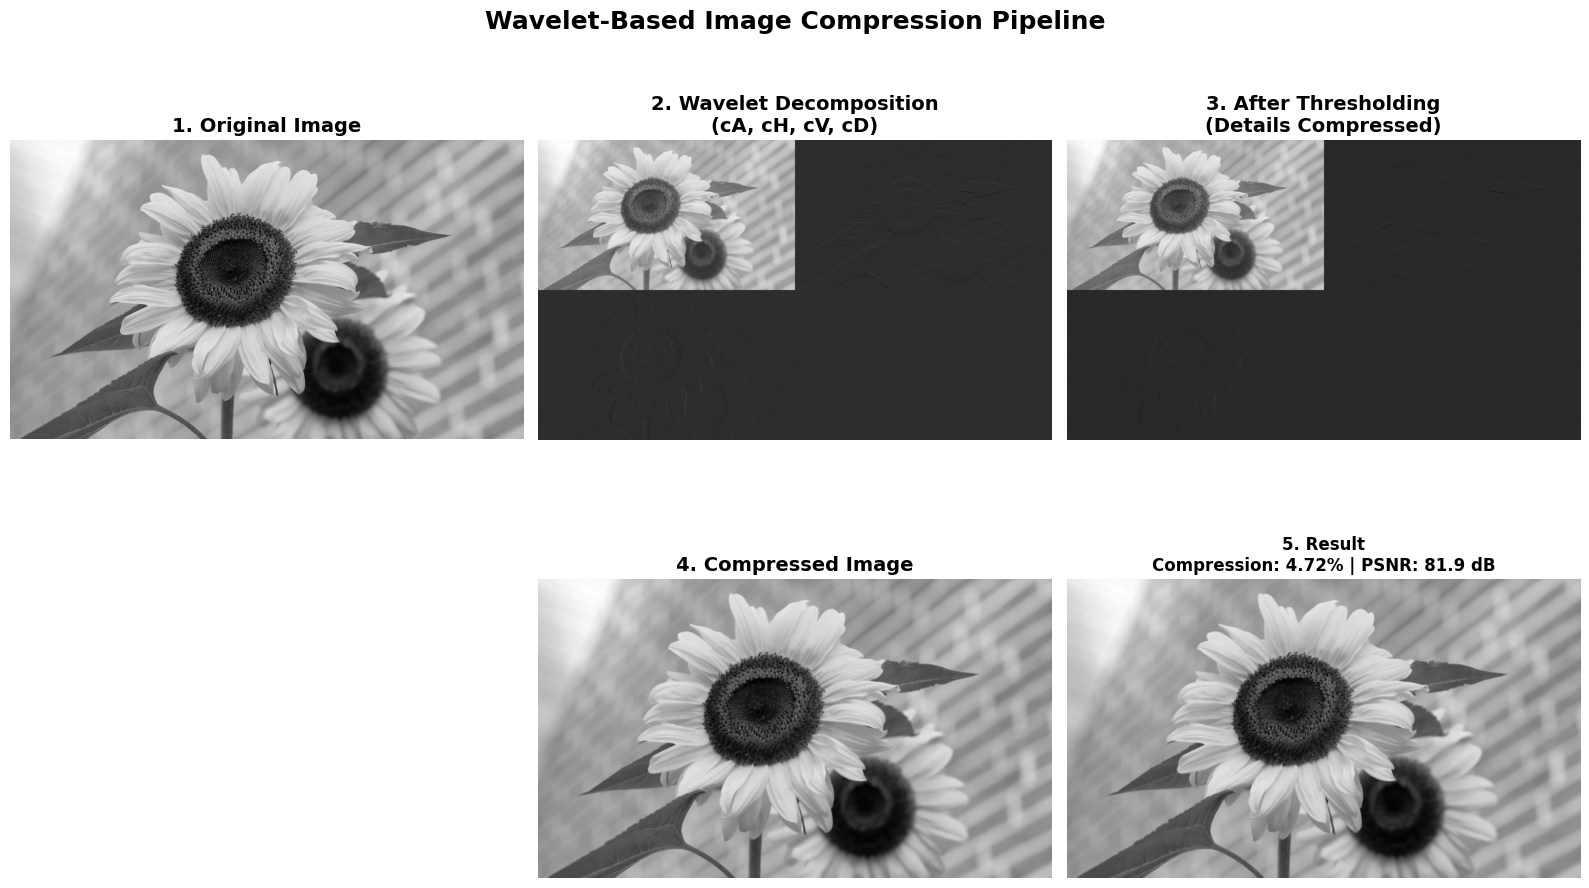

Compression ratio: 4.72%
PSNR: 81.90 dB


In [ ]:
fig = plt.figure(figsize=(18, 12))


ax1 = plt.subplot(3, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image", fontsize=12, fontweight="bold")
plt.axis("off")


plt.subplot(3, 4, 2)
plt.imshow(cA, cmap="gray")
plt.title("Approximation (cA)", fontsize=10)
plt.axis("off")

plt.subplot(3, 4, 3)
plt.imshow(cH, cmap="gray")
plt.title("Horizontal Details (cH)", fontsize=10)
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(cV, cmap="gray")
plt.title("Vertical Details (cV)", fontsize=10)
plt.axis("off")


plt.subplot(3, 4, 6)
plt.imshow(cA, cmap="gray")
plt.title("Approximation (cA)\nUnchanged", fontsize=10)
plt.axis("off")

plt.subplot(3, 4, 7)
plt.imshow(cH_thresh, cmap="gray")
plt.title("Horizontal (cH)\nAfter Thresholding", fontsize=10)
plt.axis("off")

plt.subplot(3, 4, 8)
plt.imshow(cV_thresh, cmap="gray")
plt.title("Vertical (cV)\nAfter Thresholding", fontsize=10)
plt.axis("off")


plt.subplot(3, 4, 5)
plt.imshow(cD, cmap="gray")
plt.title("Diagonal Details (cD)", fontsize=10)
plt.axis("off")


plt.subplot(3, 4, 9)
plt.imshow(cD_thresh, cmap="gray")
plt.title("Diagonal (cD)\nAfter Thresholding", fontsize=10)
plt.axis("off")


plt.subplot(3, 4, 11)
plt.imshow(compressed_img, cmap="gray")
plt.title("Compressed Image", fontsize=12, fontweight="bold")
plt.axis("off")

plt.suptitle(
    "Wavelet-Based Image Compression Process", fontsize=16, fontweight="bold", y=0.98
)
plt.tight_layout()
plt.show()

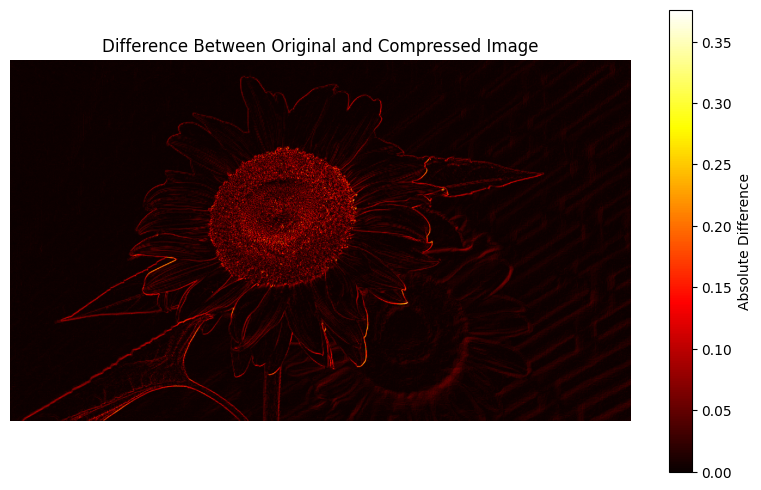

In [18]:
difference = np.abs(img - compressed_img)
plt.figure(figsize=(10, 6))
plt.imshow(difference, cmap="hot")
plt.colorbar(label="Absolute Difference")
plt.title("Difference Between Original and Compressed Image")
plt.axis("off")
plt.show()